# 6. Sweep, part 2: the curves (no GPU needed)

Replays the stored candidates at many settings and scores each one.

**Relative sweep.** The models' own rule - keep a point at least `adapt_ts` of
its patch's peak - traced from 0.05 to 0.9, with the patch-level floor held at
the headline 0.1. It answers: how much do the headline numbers depend on the
0.3 that was fixed in advance?

**Absolute sweep.** Every local maximum scoring at least *t*, for *t* from 0.02
to 0.95 - the conventional precision-recall curve, summarised as **average
precision**, with 95% intervals from resampling the 43 source mosaics, and a
paired comparison of OWL-D against caribou-owl-c on identical resamples. It is
repeated for the interior of each patch, because notebook 04 found that half
of all errors sit in the 16 px border band: matching stays whole-patch and the
band is only left out of the counting, as in notebook 04. Interior average
precision is computed over different animals and detections than the
full-patch value, so compare models within a panel, not across panels.

**Description, not selection.** CAH 2022 is the locked test domain. No
threshold is chosen here. Where a curve's best F1 is shown, it is an oracle
bound picked on the test set, and it is labelled so. The headline stays the
evaluation setting.

Every model's measured precision is a lower bound at every threshold: notebook
04 found real caribou among the "false alarms". That affects the height of the
curves, most for the models that find the most animals.


In [1]:
# --- 0. Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# --- 1. Configuration ---
import numpy as np

ASSETS  = "/content/drive/MyDrive/OWL_Caribou_Project"
RESULTS = "/content/drive/MyDrive/owl_caribou_overhead/results"

RUN_NAME = "full_cah"
MODELS   = ["owl-d", "caribou-owl-c", "owl-c", "owl-t"]
RADIUS   = 20.0
RELATIVE = np.round(np.arange(0.05, 0.901, 0.05), 3)      # adapt_ts; 0.3 is the headline setting
ABSOLUTE = np.round(np.arange(0.02, 0.951, 0.01), 3)      # absolute score thresholds
N_BOOT, SEED = 2000, 0
PAIR = ("owl-d", "caribou-owl-c")

from pathlib import Path
if not (Path(ASSETS) / "data" / "test" / "gt.csv").is_file():
    raise RuntimeError(f"{ASSETS}/data/test/gt.csv not found. Put the assets there as the README's "
                       "'Expected assets' section describes, or point ASSETS at where they are.")


In [ ]:
# === CODE SYNC (auto-generated by `python -m owlcaribou.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m owlcaribou.sync   and reopen this notebook.")

In [4]:
# --- 3. Start the session (no GPU needed) ---
from owlcaribou.session import start_session

session = start_session(assets=ASSETS, results=RESULTS, require_gpu=False, verify_assets=False)

session: Colab | device cuda (NVIDIA A100-SXM4-40GB, 39.49 GB)
  torch   2.11.0+cu128 | CUDA 12.8 | Python 3.13.15
  assets  /content/drive/MyDrive/OWL_Caribou_Project
  results /content/drive/MyDrive/owl_caribou_overhead/results
  code    c26c4d3f466e


In [5]:
# --- 4. Load candidates, and check once more that they replay the full run ---
from owlcaribou import io as oio, metrics, sweep as S
from owlcaribou.data import load_ground_truth, mosaic_from_patch_name, verify_mosaic_rule

run = session.paths.run_dir(RUN_NAME)
out = run / "sweep"
truth = load_ground_truth(session.paths.ground_truth)
patch_names = [row["images"] for row in oio.read_csv(run / MODELS[0] / "per_image.csv")]
assert len(patch_names) == 2607
verify_mosaic_rule(patch_names, truth)
groups = [mosaic_from_patch_name(n) for n in patch_names]

# The full-run detections must come from one run of one code version.
run_code = oio.require_one_run(run, MODELS)
print(f"detections: one run of all {len(MODELS)} models, code {run_code}")
sweep_code = oio.require_one_run(out, MODELS, producer="05_sweep_gpu")
print(f"candidates: one run of all {len(MODELS)} models, code {sweep_code}")

tables = {}
for model in MODELS:
    if not oio.is_complete(out / model, model=model, reproduced=True):
        raise RuntimeError(f"{model}: no reproduced candidate set; run 05_sweep_gpu first")
    table = S.CandidateTable.load(out / model / "candidates.npz")
    assert table.names == patch_names, f"{model}: candidate patch order differs"
    check = S.reproduces(table, metrics.load_predictions(run / model / "detections.csv"))
    assert check["differing"] == 0, (model, check)
    tables[model] = table
    print(f"{model:14s} {len(table):>10,} candidates, lowest absolute threshold covered "
          f"{table.minimum_absolute_threshold:.4f}; replay at the evaluation setting identical")
assert ABSOLUTE.min() >= max(t.minimum_absolute_threshold for t in tables.values())

detections: one run of all 4 models, code c26c4d3f466e
candidates: one run of all 4 models, code c26c4d3f466e
owl-d             381,218 candidates, lowest absolute threshold covered 0.0064; replay at the evaluation setting identical
caribou-owl-c   3,111,123 candidates, lowest absolute threshold covered 0.0055; replay at the evaluation setting identical
owl-c           2,430,566 candidates, lowest absolute threshold covered 0.0074; replay at the evaluation setting identical
owl-t           2,738,521 candidates, lowest absolute threshold covered 0.0079; replay at the evaluation setting identical


F1 by adapt_ts (neg_ts 0.1); the headline value is 0.3
model           0.05  0.10  0.15  0.20  0.25  0.30  0.35  0.40  0.45  0.50  0.55  0.60  0.65  0.70  0.75  0.80  0.85  0.90
owl-d          0.910 0.944 0.955 0.959 0.961 0.962 0.963 0.962 0.960 0.957 0.953 0.948 0.940 0.930 0.910 0.877 0.804 0.661
caribou-owl-c  0.314 0.782 0.891 0.921 0.936 0.946 0.953 0.958 0.961 0.963 0.962 0.950 0.930 0.892 0.828 0.733 0.611 0.485
owl-c          0.500 0.738 0.807 0.836 0.851 0.857 0.860 0.857 0.853 0.847 0.837 0.827 0.813 0.792 0.764 0.723 0.652 0.537
owl-t          0.596 0.786 0.839 0.861 0.870 0.874 0.874 0.872 0.870 0.865 0.860 0.851 0.839 0.826 0.806 0.774 0.705 0.581

empty-patch false-alarm rate by adapt_ts (set by the 0.1 floor alone, so it does not move)
owl-d          0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013 0.013
caribou-owl-c  0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.062 0.06

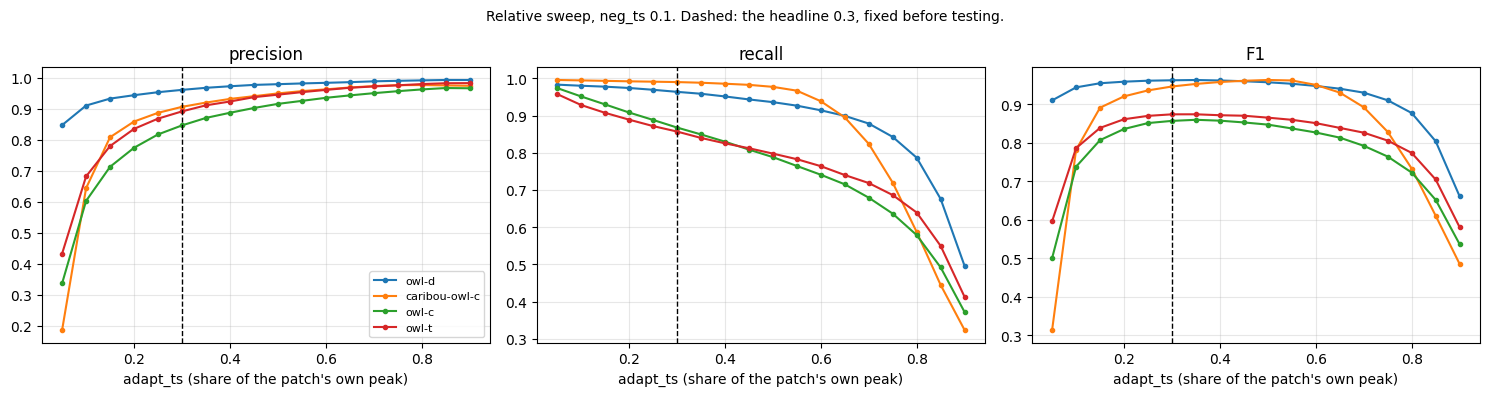

In [6]:
# --- 5. Relative sweep: how much does the fixed 0.3 matter? ---
import matplotlib.pyplot as plt

relative = {m: S.trace(tables[m], truth, patch_names, RADIUS, "relative", RELATIVE, model=m)
            for m in MODELS}
oio.write_csv(out / "relative_sweep.csv", [r for c in relative.values() for r in c.rows()])

print("F1 by adapt_ts (neg_ts 0.1); the headline value is 0.3")
print("model          " + " ".join(f"{v:5.2f}" for v in RELATIVE))
for m, c in relative.items():
    print(f"{m:14s} " + " ".join(f"{f:5.3f}" for f in c.pooled["f1_score"]))

print("\nempty-patch false-alarm rate by adapt_ts (set by the 0.1 floor alone, so it does not move)")
for m, c in relative.items():
    print(f"{m:14s} " + " ".join(f"{f:5.3f}" for f in c.pooled["empty_patch_false_positive_rate"]))

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for m, c in relative.items():
    for axis, metric in zip(axes, ("precision", "recall", "f1_score")):
        axis.plot(c.values, c.pooled[metric], marker="o", markersize=3, label=m)
for axis, metric in zip(axes, ("precision", "recall", "F1")):
    axis.axvline(0.3, color="black", linestyle="--", linewidth=1)
    axis.set_xlabel("adapt_ts (share of the patch's own peak)")
    axis.set_title(metric)
    axis.grid(alpha=0.3)
axes[0].legend(fontsize=8)
figure.suptitle("Relative sweep, neg_ts 0.1. Dashed: the headline 0.3, fixed before testing.", fontsize=10)
plt.tight_layout()
plt.savefig(out / "relative_sweep.png", dpi=160)
plt.show()


average precision, full patches (43 mosaics x 2000 resamples)
  owl-d          AP 0.978 [0.974, 0.984]   oracle best F1 0.963 (chosen on the test set - not a result)
  caribou-owl-c  AP 0.977 [0.973, 0.983]   oracle best F1 0.966 (chosen on the test set - not a result)
  owl-c          AP 0.919 [0.897, 0.935]   oracle best F1 0.861 (chosen on the test set - not a result)
  owl-t          AP 0.927 [0.915, 0.944]   oracle best F1 0.876 (chosen on the test set - not a result)
  owl-d minus caribou-owl-c: +0.0011 [-0.0044, +0.0079], owl-d ahead in 57.4% of resamples

average precision, interior only (band matched, not counted) (43 mosaics x 2000 resamples)
  owl-d          AP 0.982 [0.977, 0.988]   oracle best F1 0.981 (chosen on the test set - not a result)
  caribou-owl-c  AP 0.984 [0.980, 0.990]   oracle best F1 0.983 (chosen on the test set - not a result)
  owl-c          AP 0.935 [0.913, 0.952]   oracle best F1 0.886 (chosen on the test set - not a result)
  owl-t          AP 0.942 

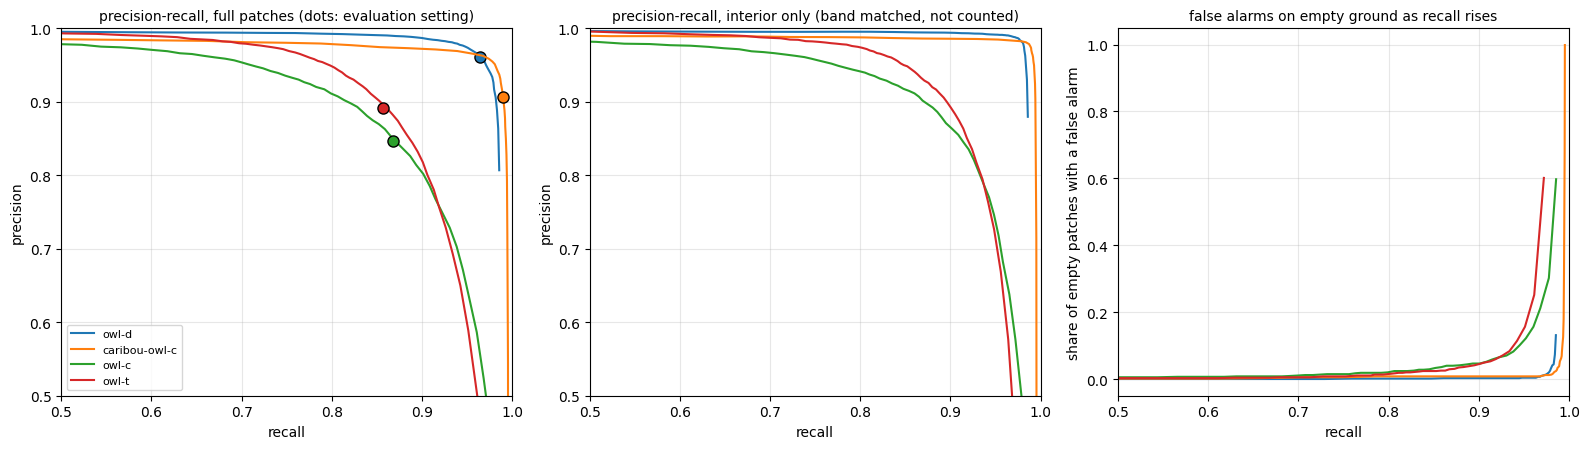

written to /content/drive/MyDrive/owl_caribou_overhead/results/full_cah/sweep


In [7]:
# --- 6. Absolute sweep: precision-recall and average precision, with error bars ---
import matplotlib.pyplot as plt

# One matching per patch per threshold gives both the full-patch and the interior curve.
both = {m: S.trace_both(tables[m], truth, patch_names, RADIUS, "absolute", ABSOLUTE, model=m)
        for m in MODELS}
curves = {(m, interior): both[m][int(interior)] for interior in (False, True) for m in MODELS}
oio.write_csv(out / "absolute_sweep.csv", [r for c in curves.values() for r in c.rows()])

summary_rows, pair_rows = [], []
for interior in (False, True):
    label = "interior only (band matched, not counted)" if interior else "full patches"
    boot = S.bootstrap_average_precision({m: curves[(m, interior)] for m in MODELS}, groups,
                                         n_boot=N_BOOT, seed=SEED)
    print(f"\naverage precision, {label} ({boot['mosaics']} mosaics x {N_BOOT} resamples)")
    for m in MODELS:
        s = boot["models"][m]
        oracle = float(np.nanmax(curves[(m, interior)].pooled["f1_score"]))
        summary_rows.append({"model": m, "interior": interior, **s, "oracle_best_f1": oracle})
        print(f"  {m:14s} AP {s['ap']:.3f} [{s['ci_low']:.3f}, {s['ci_high']:.3f}]   "
              f"oracle best F1 {oracle:.3f} (chosen on the test set - not a result)")
    d = boot["difference"](*PAIR)
    pair_rows.append({"interior": interior, **d})
    print(f"  {PAIR[0]} minus {PAIR[1]}: {d['estimate']:+.4f} [{d['ci_low']:+.4f}, {d['ci_high']:+.4f}], "
          f"{PAIR[0]} ahead in {d['share_a_better']:.1%} of resamples")
oio.write_csv(out / "average_precision.csv", summary_rows)
oio.write_csv(out / "average_precision_pair.csv", pair_rows)

headline = {m: relative[m].at(0.3) for m in MODELS}
figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for m in MODELS:
    for axis, interior in zip(axes[:2], (False, True)):
        c = curves[(m, interior)]
        line, = axis.plot(c.pooled["recall"], c.pooled["precision"], label=m)
        if not interior:
            axis.plot(headline[m]["recall"], headline[m]["precision"], "o", color=line.get_color(),
                      markersize=8, markeredgecolor="black")
    c = curves[(m, False)]
    axes[2].plot(c.pooled["recall"], c.pooled["empty_patch_false_positive_rate"], label=m)
for axis, title in zip(axes[:2], ("precision-recall, full patches (dots: evaluation setting)",
                                  "precision-recall, interior only (band matched, not counted)")):
    axis.set_xlabel("recall"); axis.set_ylabel("precision"); axis.set_title(title, fontsize=10)
    axis.set_xlim(0.5, 1.0); axis.set_ylim(0.5, 1.0); axis.grid(alpha=0.3)
axes[2].set_xlabel("recall"); axes[2].set_ylabel("share of empty patches with a false alarm")
axes[2].set_title("false alarms on empty ground as recall rises", fontsize=10)
axes[2].set_xlim(0.5, 1.0); axes[2].grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(out / "precision_recall.png", dpi=160)
plt.show()

session.record(out, radius=RADIUS, relative=RELATIVE.tolist(), absolute=ABSOLUTE.tolist(),
               n_boot=N_BOOT, seed=SEED)
print("written to", out)

## Reading the curves

**Relative sweep.** A flat F1 line around 0.3 means the fixed operating point
was not doing much work: the ranking would hold at other settings. A steep one
means the result is fragile to that choice.

**Average precision.** The threshold-free comparison. If the paired interval
excludes zero, one model ranks animals above background more reliably than the
other across *all* settings, not just the fixed one. If it includes zero,
neither is better on that measure.

**Interior curves.** Scored over interior animals and detections only, with
the matching done on the whole patch first. Interior average precision is
computed over different animals and detections than the full-patch value, so
compare models within one printed block, not across blocks; the full-patch
block is the headline.

**Evaluation-setting dots.** Where each model's evaluated point sits on its
own curve: far from the top-right corner means the fixed rule left performance
on the table for that model - or bought precision with recall, depending on
direction. The dot comes from the relative rule, so it need not lie exactly on
the absolute curve.

**Oracle best F1.** Chosen on the test set. It shows headroom, and it must not
be reported as a model's performance.

## Limits

- Precision is a lower bound everywhere: real caribou missing from the ground
  truth count as false alarms at every threshold.
- The curve is sampled at score thresholds 0.01 apart, so each average
  precision is a lower bound on the exact all-points area. How far below
  depends on how each model's scores are spread, which differs between
  models; a shared grid does not make that equal, so differences of about
  0.001 are within the approximation.
- Absolute thresholds compare raw scores across models whose heads were
  trained differently. The curve shape is comparable; a given *t* is not.
